# Visualização dos dados — Trabalho 1

Notebook para **carregar e exibir** os quatro conjuntos de dados do trabalho.

Cada arquivo CSV contém as colunas `n` (índice), `u` (entrada) e `y` (saída).
Não há análise estatística ou espectral aqui — apenas inspeção visual.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "dados_treino_branco.csv").exists():
    DATA_DIR = PROJECT_ROOT
elif (PROJECT_ROOT.parent / "dados_treino_branco.csv").exists():
    DATA_DIR = PROJECT_ROOT.parent
else:
    DATA_DIR = PROJECT_ROOT / "data"

DATASETS = {
    "Treino — entrada branca": "dados_treino_branco.csv",
    "Validação — entrada branca": "dados_validacao_branco.csv",
    "Treino — entrada colorida": "dados_treino_colorido.csv",
    "Teste — anomalia": "dados_teste_anomalia.csv",
}

In [2]:
data = {}

for label, filename in DATASETS.items():
    path = DATA_DIR / filename
    df = pd.read_csv(path)
    data[label] = df
    print(f"{label}")
    print(f"  arquivo: {path.name}")
    print(f"  amostras: {len(df)}")
    print(f"  colunas: {list(df.columns)}")
    print()

Treino — entrada branca
  arquivo: dados_treino_branco.csv
  amostras: 5000
  colunas: ['n', 'u', 'y']

Validação — entrada branca
  arquivo: dados_validacao_branco.csv
  amostras: 3000
  colunas: ['n', 'u', 'y']

Treino — entrada colorida
  arquivo: dados_treino_colorido.csv
  amostras: 5000
  colunas: ['n', 'u', 'y']

Teste — anomalia
  arquivo: dados_teste_anomalia.csv
  amostras: 5000
  colunas: ['n', 'u', 'y']



In [3]:
for label, df in data.items():
    display(label)
    display(df.head())
    display(df.tail())

'Treino — entrada branca'

,n,u,y
0,0,-1.103338,-0.036742
1,1,-0.725025,-0.170477
2,2,-0.781805,-0.375676
3,3,0.266976,-0.558156
4,4,-0.248581,-0.491399


,n,u,y
4995,4995,-0.682916,0.355904
4996,4996,1.362498,0.282760
4997,4997,-0.804139,0.289557
4998,4998,0.306004,0.147349
4999,4999,0.068949,0.203570


'Validação — entrada branca'

,n,u,y
0,0,-0.359668,0.035662
1,1,1.203675,0.051414
2,2,1.396868,0.217445
3,3,0.317236,0.454214
4,4,0.414134,0.590228


...

,n,u,y
0,0,0.819882,0.002527
1,1,1.083911,0.216975
2,2,0.416324,0.213630
3,3,0.243489,0.651639
4,4,0.057672,0.556680


,n,u,y
4995,4995,-0.812483,0.066740
4996,4996,-0.833867,-0.260140
4997,4997,-1.001516,-0.275902
4998,4998,-1.671863,-0.623971
4999,4999,-2.394336,-0.862301


'Teste — anomalia'

,n,u,y
0,0,-1.142092,-0.148352
1,1,-1.069337,-0.178310
2,2,-0.757258,-0.450165
3,3,0.768658,-0.614032
4,4,-1.037935,-0.691373


,n,u,y
4995,4995,-0.554717,-0.826238
4996,4996,-0.249957,-0.748380
4997,4997,-0.313065,-0.711184
4998,4998,-0.414624,-0.690892
4999,4999,0.797966,-0.604689


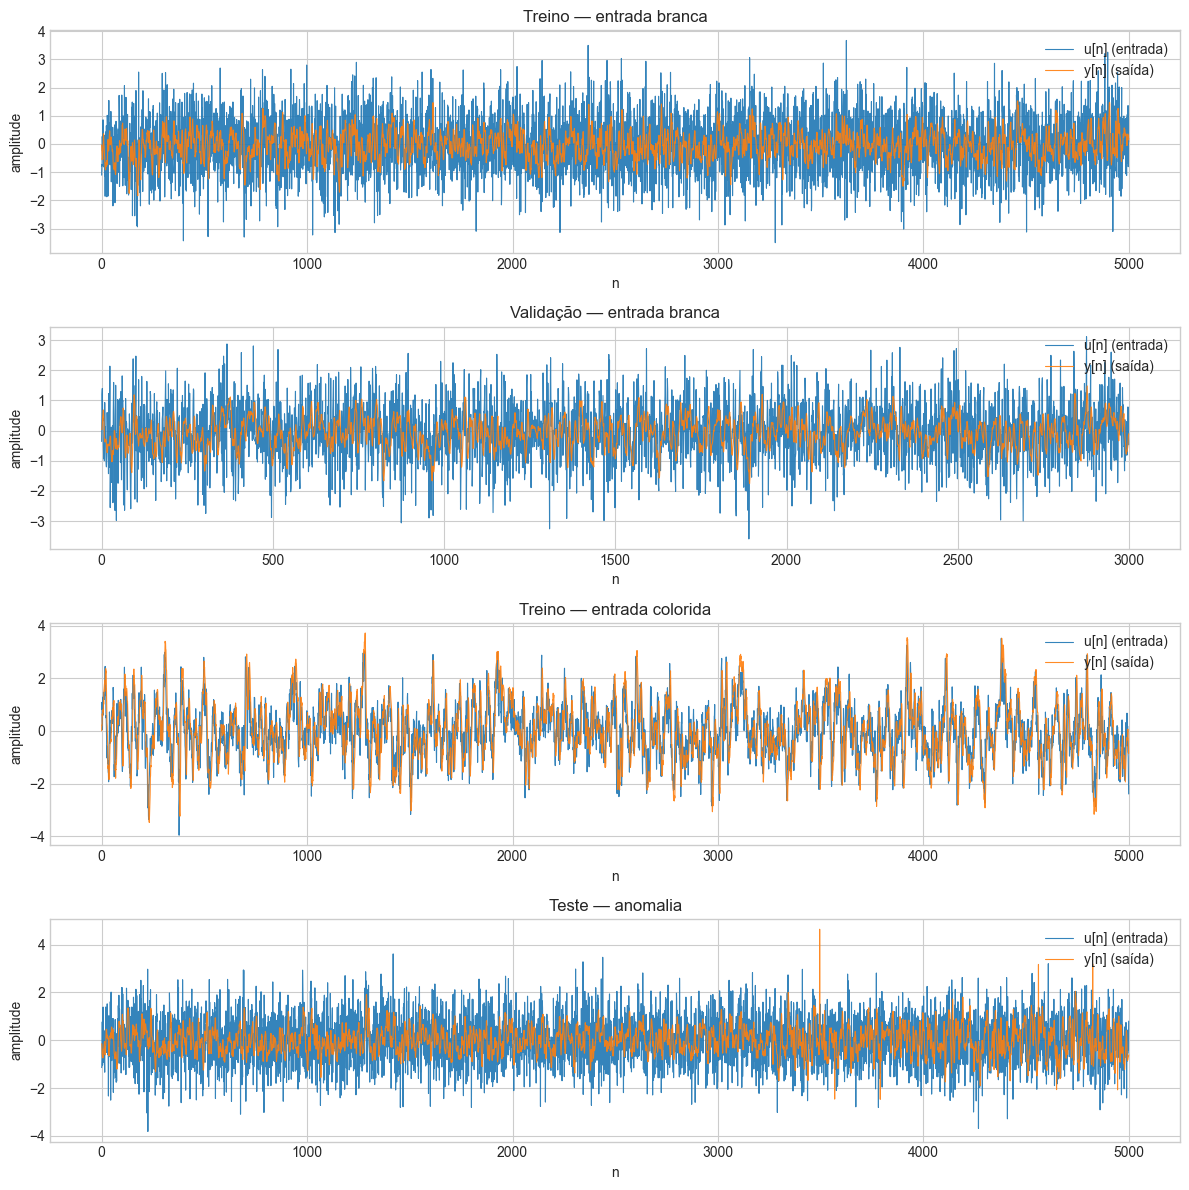

In [4]:
fig, axes = plt.subplots(len(data), 1, figsize=(12, 3 * len(data)), sharex=False)

if len(data) == 1:
    axes = [axes]

for ax, (label, df) in zip(axes, data.items()):
    ax.plot(df["n"], df["u"], label="u[n] (entrada)", linewidth=0.8, alpha=0.9)
    ax.plot(df["n"], df["y"], label="y[n] (saída)", linewidth=0.8, alpha=0.9)
    ax.set_title(label)
    ax.set_xlabel("n")
    ax.set_ylabel("amplitude")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

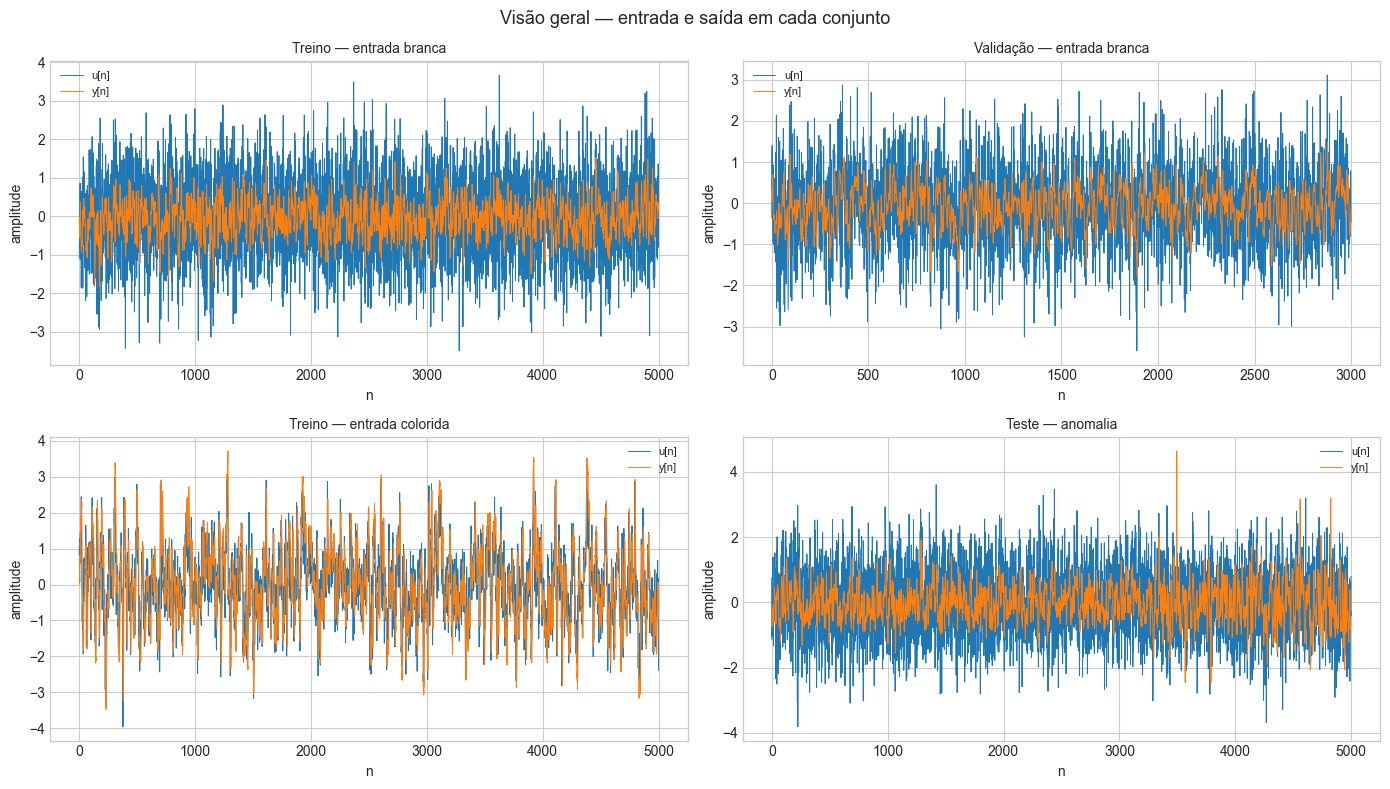

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, (label, df) in zip(axes, data.items()):
    ax.plot(df["n"], df["u"], label="u[n]", linewidth=0.7)
    ax.plot(df["n"], df["y"], label="y[n]", linewidth=0.7)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("n")
    ax.set_ylabel("amplitude")
    ax.legend(fontsize=8)

plt.suptitle("Visão geral — entrada e saída em cada conjunto", fontsize=13)
plt.tight_layout()
plt.show()